In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from copula_mp import mp_density, mp_density_t_learner
from copula_mp_iv import mp_density_iv

## The effect of institutions on economic growth

In [25]:
# load data and partial out residuals
d = pd.read_csv("Data/AJR_Data.csv")

y_raw = d['GDP'].values
x_raw = d['Exprop'].values
z_raw = d['logMort'].values

""" # Create covariate matrix W (Intercept + Latitude)
ones = np.ones(len(d))
W = np.column_stack([ones, d['Latitude'].values])

# Construct the Residual Maker Matrix (M_W = I - W(W'W)⁻¹W')
# This "projects out" the covariates from the variables
I = np.eye(len(W))
W_inv_W = np.linalg.inv(W.T @ W)
M_W = I - W @ W_inv_W @ W.T

# Project out covariates to get the residuals
y = M_W @ y_raw
x = M_W @ x_raw
z = M_W @ z_raw """

y = y_raw
x = x_raw
z = z_raw

In [26]:
# define parameters
y_grid = np.linspace(y.min() - 0.5, y.max() + 0.5, 50)
T_fwd, B_post = 500, 100

# fit martingale posteriors and compute density estimates for S-Learner
res = mp_density_iv(y, x, z, [4, 8], y_grid, B_post, T_fwd)
res_4, res_8 = res['x_0'], res['x_1']


First-stage estimation:
  Estimated coefficients: [[ 9.365895  ]
 [-0.61328927]]
  Mean residual: 0.000000
  Std residual: 1.242142
Compiling...
Compilation time: 0.017s
Optimizing...
Optimization time: 0.075s
Fitting...
Fit time: 0.002s

Conditional density fit:
  Optimised rho: 0.8001927137374878
  Optimised rho_x: [0.80167735 0.80114526]
  Prequential log-likelihood: -50.14349365234375
Predicting...
Prediction time: 0.158s
Predictive resampling (IV-modified)...
Predictive resampling time: 4.589s


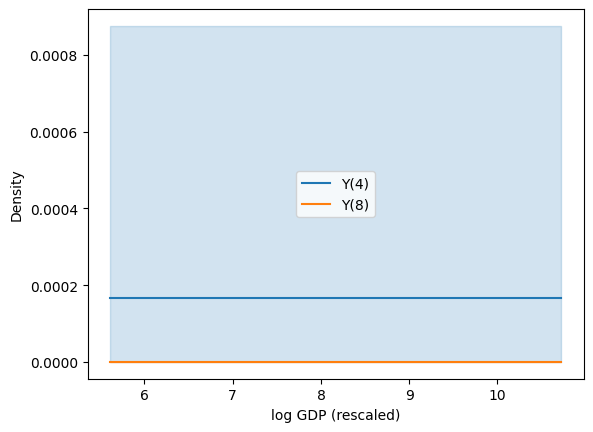

In [27]:

plt.plot(y_grid, res_4['mean'], label="Y(4)", color='tab:blue')
plt.fill_between(y_grid, res_4['low'], res_4['high'], color='tab:blue', alpha=0.2)

plt.plot(y_grid, res_8['mean'], label="Y(8)", color='tab:orange')
plt.fill_between(y_grid, res_8['low'], res_8['high'], color='tab:orange', alpha=0.2)

#plt.xscale('log')
plt.xlabel("log GDP (rescaled)")
plt.ylabel("Density") 
plt.legend()

plt.show()